/var/folders/p_/cll8k7v52w53ryw2zkx4h0pm0000gp/T/ipykernel_31484/3061513098.py:47: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', frameon=True, fontsize=12)


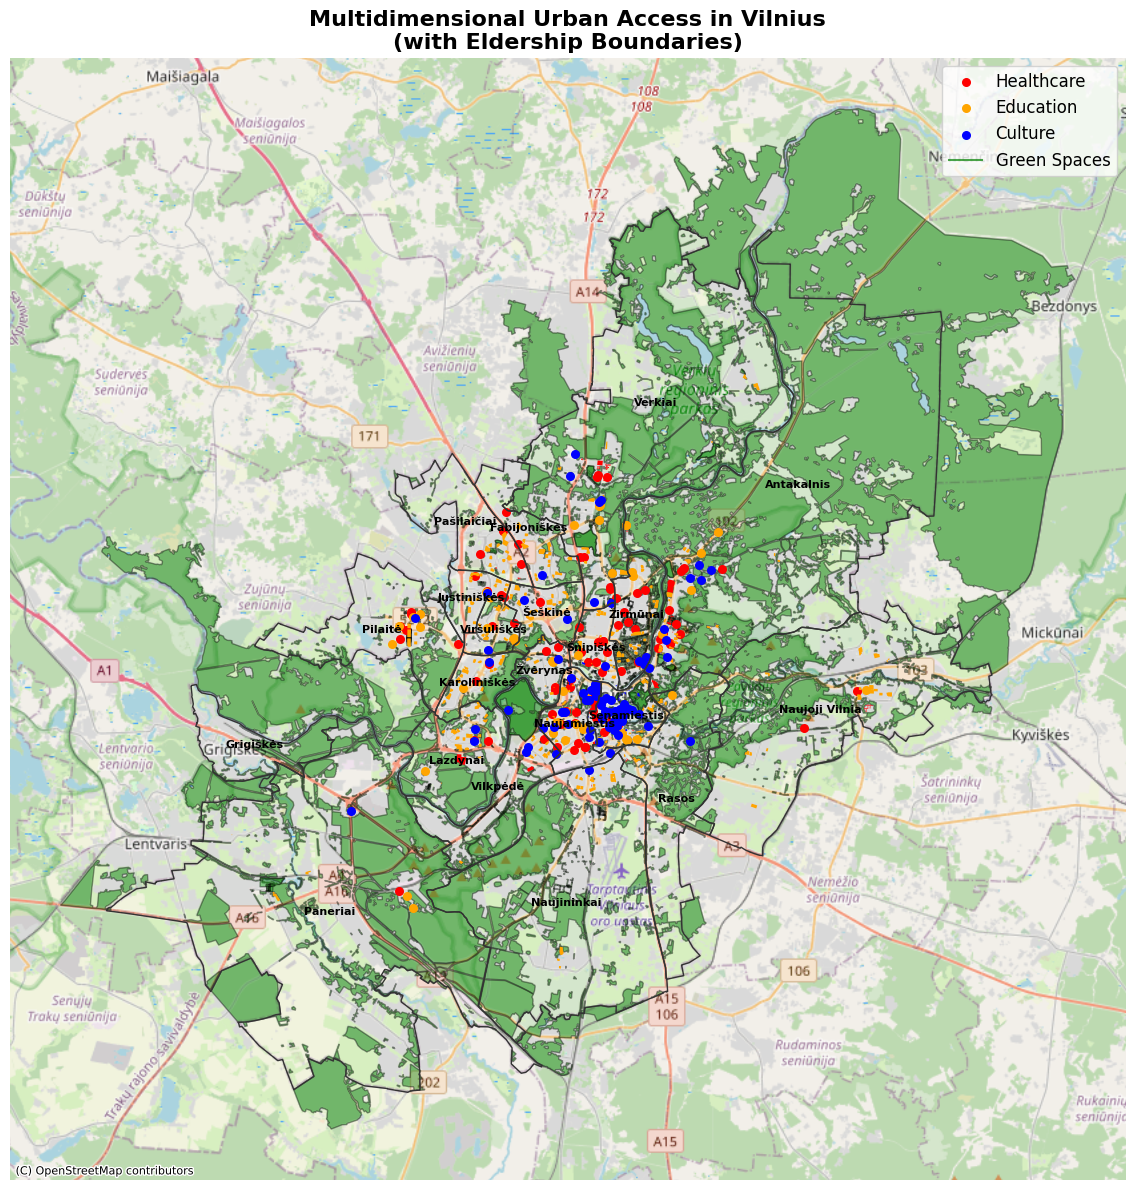

In [72]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

# Layers (EPSG:3857)
green_3857 = gpd.read_file("../data/processed/green_vilnius_cleaned.geojson").to_crs("EPSG:3857")
health_3857 = gpd.read_file("../data/processed/health_vilnius_cleaned.geojson").to_crs("EPSG:3857")
edu_3857 = gpd.read_file("../data/processed/education_vilnius_cleaned.geojson").to_crs("EPSG:3857")
culture_3857 = gpd.read_file("../data/processed/culture_vilnius_cleaned.geojson").to_crs("EPSG:3857")

# Elderships
elderships = gpd.read_file("../data/raw/vilnius_elderships.geojson")
elderships_3857 = elderships.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(12, 12))

green_3857.plot(ax=ax, color='green', edgecolor='black', alpha=0.4)
health_3857.plot(ax=ax, color='red', markersize=30, label='Healthcare')
edu_3857.plot(ax=ax, color='orange', markersize=30, label='Education')
culture_3857.plot(ax=ax, color='blue', markersize=30, label='Culture')

# Dummy plot for green in legend
ax.plot([], [], color='green', alpha=0.7, label='Green Spaces')

# ELDERSHIP BOUNDARIES
elderships_3857.boundary.plot(
    ax=ax,
    color='#333333',
    linewidth=1.0,
    linestyle='-',
    alpha=1
)
# Eldership labels
for idx, row in elderships_3857.iterrows():
    name = row['SENIUNIJA']
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, name, fontsize=8, ha='center', va='center',
            color='black', fontweight='bold')

# Basemap
cx.add_basemap(ax, crs="EPSG:3857", source=cx.providers.OpenStreetMap.Mapnik)

# Customization
ax.set_title("Multidimensional Urban Access in Vilnius\n(with Eldership Boundaries)", fontsize=16, fontweight='bold')
ax.set_axis_off()
ax.legend(loc='upper right', frameon=True, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Cleaned service layers
green_clean = gpd.read_file("../data/processed/green_vilnius_cleaned.geojson")
health_clean = gpd.read_file("../data/processed/health_vilnius_cleaned.geojson")
education_clean = gpd.read_file("../data/processed/education_vilnius_cleaned.geojson")
culture_clean = gpd.read_file("../data/processed/culture_vilnius_cleaned.geojson")

# Load eldership boundaries and population
pop = pd.read_csv("../data/raw/eldershippopulation.csv")

# OSM layers reproject to eldership crs
target_crs = elderships.crs
green_clean = green_clean.to_crs(target_crs)
health_clean = health_clean.to_crs(target_crs)
education_clean = education_clean.to_crs(target_crs)
culture_clean = culture_clean.to_crs(target_crs)

In [81]:
green_points = green_clean.copy()
green_points.geometry = green_clean.geometry.centroid

# Features per eldership
def count_features_in_elderships(gdf_points, elderships_gdf, eldership_col='SENIUNIJA'):
    joined = gpd.sjoin(gdf_points, elderships_gdf[[eldership_col, 'geometry']], how='inner', predicate='within')
    counts = joined.groupby(eldership_col).size()
    return counts


green_intersect = gpd.overlay(green_clean, elderships[['SENIUNIJA', 'geometry']], how='intersection')
green_area = green_intersect.groupby('SENIUNIJA')['area_ha'].sum()

health_count = count_features_in_elderships(health_clean, elderships)
education_count = count_features_in_elderships(education_clean, elderships)
culture_count = count_features_in_elderships(culture_clean, elderships)

/var/folders/p_/cll8k7v52w53ryw2zkx4h0pm0000gp/T/ipykernel_31484/520894690.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  green_points.geometry = green_clean.geometry.centroid


In [82]:
# Start with elderships GeoDataFrame
df = elderships[['SENIUNIJA', 'geometry']].copy()

# Merge population
df = df.merge(pop, left_on='SENIUNIJA', right_on='eldership_name', how='left')
df = df.drop(columns=['eldership_name'])

# Merge service counts/area
df = df.merge(green_area.rename('green_area_ha'), on='SENIUNIJA', how='left')
df = df.merge(health_count.rename('health_count'), on='SENIUNIJA', how='left')
df = df.merge(education_count.rename('education_count'), on='SENIUNIJA', how='left')
df = df.merge(culture_count.rename('culture_count'), on='SENIUNIJA', how='left')

# Densities per 1,000 residents
df['green_area_per_1000'] = df['green_area_ha'] / (df['population'] / 1000)
df['health_per_1000'] = df['health_count'] / (df['population'] / 1000)
df['education_per_1000'] = df['education_count'] / (df['population'] / 1000)
df['culture_per_1000'] = df['culture_count'] / (df['population'] / 1000)

df.to_file("../data/processed/eldership_equity_metrics.geojson", driver='GeoJSON')
df.drop(columns='geometry').to_csv("../data/processed/eldership_equity_metrics.csv", index=False)

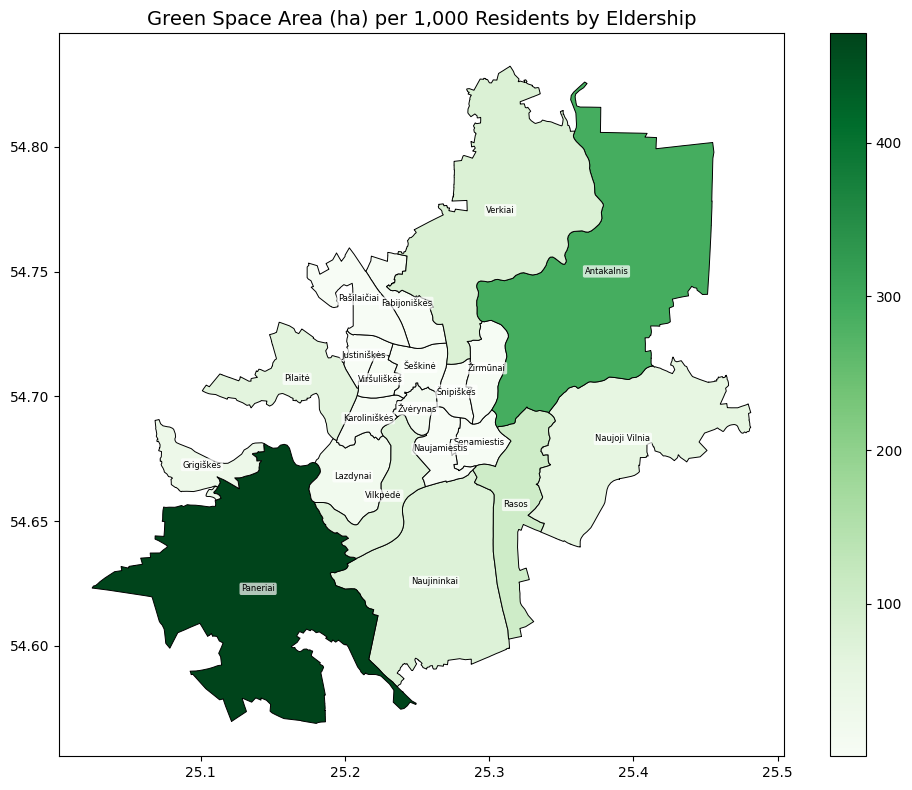

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
df.plot(column='green_area_per_1000', legend=True, ax=ax, cmap='Greens', edgecolor='black', linewidth=0.7)

for idx, row in df.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        row['SENIUNIJA'],
        fontsize=6,
        ha='center', va='center',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )

ax.set_title('Green Space Area (ha) per 1,000 Residents by Eldership', fontsize=14)
plt.tight_layout()
plt.savefig("../docs/green_per_1000_choropleth.png", dpi=150)
plt.show()

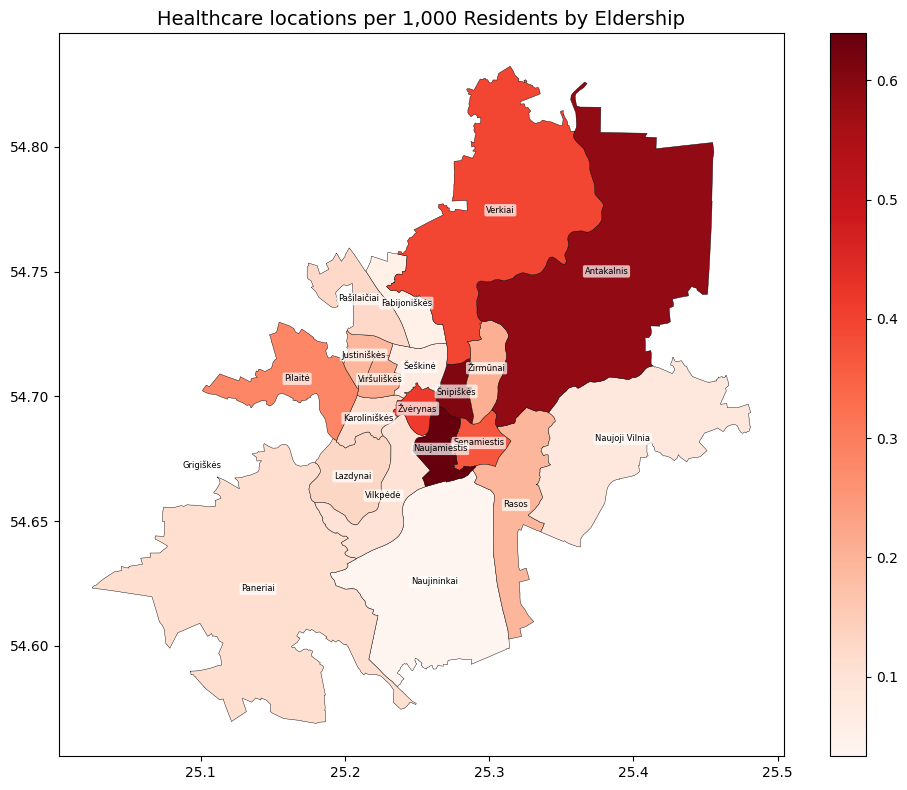

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
df.plot(column='health_per_1000', legend=True, ax=ax, cmap='Reds', edgecolor='black', linewidth=0.3)

for idx, row in df.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        row['SENIUNIJA'],
        fontsize=6,
        ha='center', va='center',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )
    
ax.set_title('Healthcare locations per 1,000 Residents by Eldership', fontsize=14)
plt.tight_layout()
plt.savefig("../docs/health_per_1000_choropleth.png", dpi=150)
plt.show()

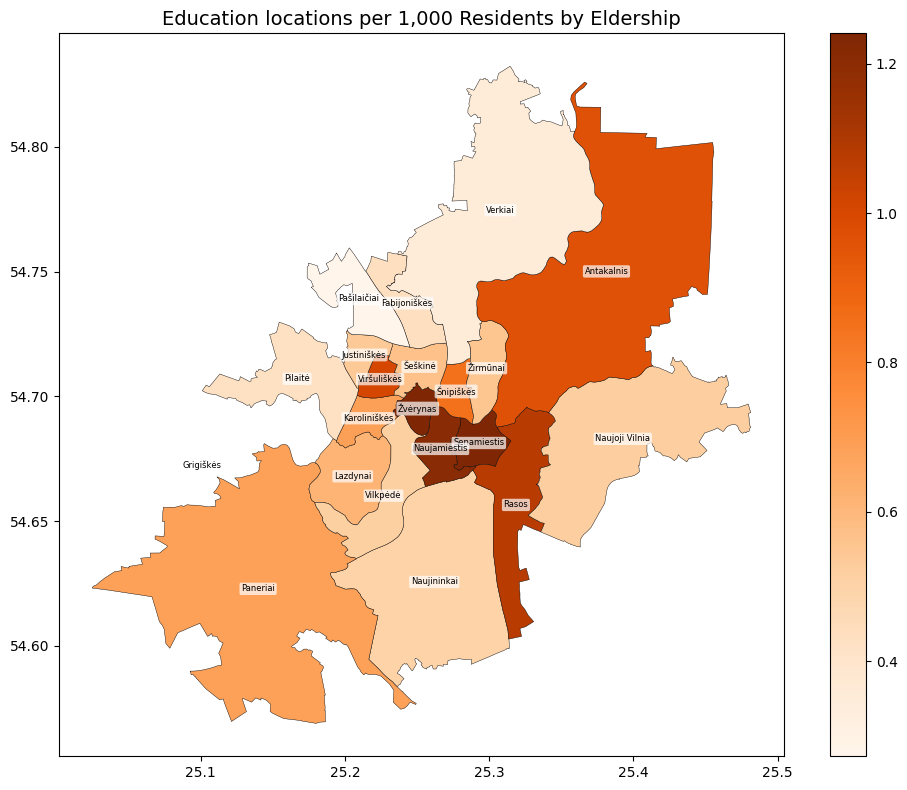

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
df.plot(column='education_per_1000', legend=True, ax=ax, cmap='Oranges', edgecolor='black', linewidth=0.3)

for idx, row in df.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        row['SENIUNIJA'],
        fontsize=6,
        ha='center', va='center',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )
    
ax.set_title('Education locations per 1,000 Residents by Eldership', fontsize=14)
plt.tight_layout()
plt.savefig("../docs/education_per_1000_choropleth.png", dpi=150)
plt.show()

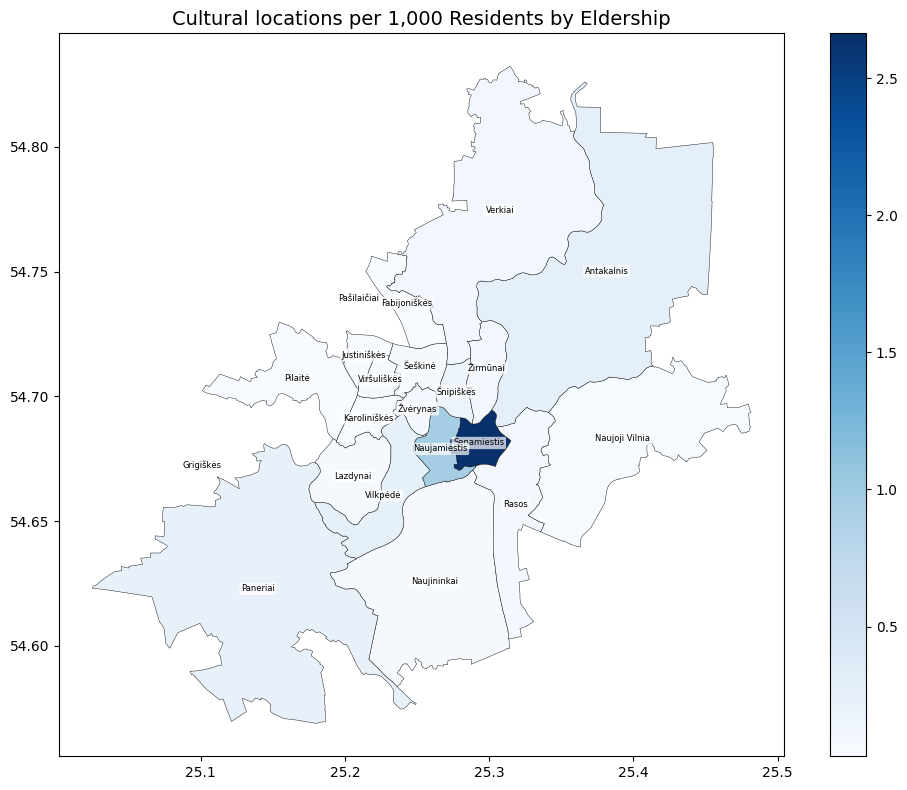

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
df.plot(column='culture_per_1000', legend=True, ax=ax, cmap='Blues', edgecolor='black', linewidth=0.3)

for idx, row in df.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y,
        row['SENIUNIJA'],
        fontsize=6,
        ha='center', va='center',
        color='black',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )
    
ax.set_title('Cultural locations per 1,000 Residents by Eldership', fontsize=14)
plt.tight_layout()
plt.savefig("../docs/culture_per_1000_choropleth.png", dpi=150)
plt.show()